# Handwritten digit recognition (MNIST): a fixed baseline and a small CNN

The first version of this notebook trained a 3-layer dense network but ran `x_test = normalize(x_train)`, which put
normalised *training* images into the test variable, so its reported test score wasn't measuring the test set.
This version fixes the preprocessing, holds out a validation split, and compares the dense baseline with a small convolutional network.

In [1]:
import numpy as np, matplotlib.pyplot as plt, tensorflow as tf
tf.random.set_seed(0); np.random.seed(0)
print("TensorFlow", tf.__version__)

try:
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    source = "keras.datasets.mnist"
except Exception:  # offline fallback: the same 70,000 MNIST images saved locally (see README)
    d = np.load("mnist_local.npz")
    x_train, y_train, x_test, y_test = d["x_train"], d["y_train"], d["x_test"], d["y_test"]
    source = "local copy (mnist_local.npz)"
print("data source:", source, "| train", x_train.shape, "| test", x_test.shape)

TensorFlow 2.21.0


data source: local copy (mnist_local.npz) | train (60000, 28, 28) | test (10000, 28, 28)


## Preprocessing: scale pixels to [0, 1], identically for train and test

In [2]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
assert x_train.max() <= 1 and x_test.max() <= 1 and len(x_test) == len(y_test)

## Model 1: the original dense network (3 × 128 ReLU), 5 epochs, 10% validation split

In [3]:
dense = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)), tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"), tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"), tf.keras.layers.Dense(10, activation="softmax")])
dense.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h_dense = dense.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=2)

Epoch 1/5


422/422 - 3s - 6ms/step - accuracy: 0.9059 - loss: 0.3244 - val_accuracy: 0.9660 - val_loss: 0.1202


Epoch 2/5


422/422 - 1s - 3ms/step - accuracy: 0.9611 - loss: 0.1289 - val_accuracy: 0.9730 - val_loss: 0.0967


Epoch 3/5


422/422 - 1s - 3ms/step - accuracy: 0.9733 - loss: 0.0877 - val_accuracy: 0.9722 - val_loss: 0.0872


Epoch 4/5


422/422 - 3s - 6ms/step - accuracy: 0.9806 - loss: 0.0634 - val_accuracy: 0.9780 - val_loss: 0.0710


Epoch 5/5


422/422 - 1s - 3ms/step - accuracy: 0.9857 - loss: 0.0471 - val_accuracy: 0.9792 - val_loss: 0.0720


## Model 2: small CNN (two conv blocks + dropout), 5 epochs

In [4]:
cnn = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, 3, activation="relu"), tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"), tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(), tf.keras.layers.Dropout(0.3), tf.keras.layers.Dense(10, activation="softmax")])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h_cnn = cnn.fit(x_train[..., None], y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=2)

Epoch 1/5


422/422 - 10s - 23ms/step - accuracy: 0.9023 - loss: 0.3258 - val_accuracy: 0.9763 - val_loss: 0.0863


Epoch 2/5


422/422 - 8s - 19ms/step - accuracy: 0.9707 - loss: 0.0957 - val_accuracy: 0.9827 - val_loss: 0.0582


Epoch 3/5


422/422 - 8s - 19ms/step - accuracy: 0.9781 - loss: 0.0719 - val_accuracy: 0.9847 - val_loss: 0.0479


Epoch 4/5


422/422 - 7s - 18ms/step - accuracy: 0.9820 - loss: 0.0594 - val_accuracy: 0.9862 - val_loss: 0.0462


Epoch 5/5


422/422 - 8s - 18ms/step - accuracy: 0.9846 - loss: 0.0506 - val_accuracy: 0.9877 - val_loss: 0.0420


## Test-set evaluation (10,000 held-out images, scored once)

In [5]:
for name, model, X in [("dense (3x128)", dense, x_test), ("CNN", cnn, x_test[..., None])]:
    loss, acc = model.evaluate(X, y_test, verbose=0)
    print(f"{name:14s} test accuracy {acc:.4f} | test loss {loss:.4f} | parameters {model.count_params():,}")

dense (3x128)  test accuracy 0.9750 | test loss 0.0856 | parameters 134,794


CNN            test accuracy 0.9875 | test loss 0.0405 | parameters 34,826


CNN per-digit accuracy: {0: 0.9949, 1: 0.9912, 2: 0.9981, 3: 0.9931, 4: 0.9847, 5: 0.9854, 6: 0.9843, 7: 0.9825, 8: 0.9856, 9: 0.9742}
most common confusion: true 7 predicted as 2 (11 images)


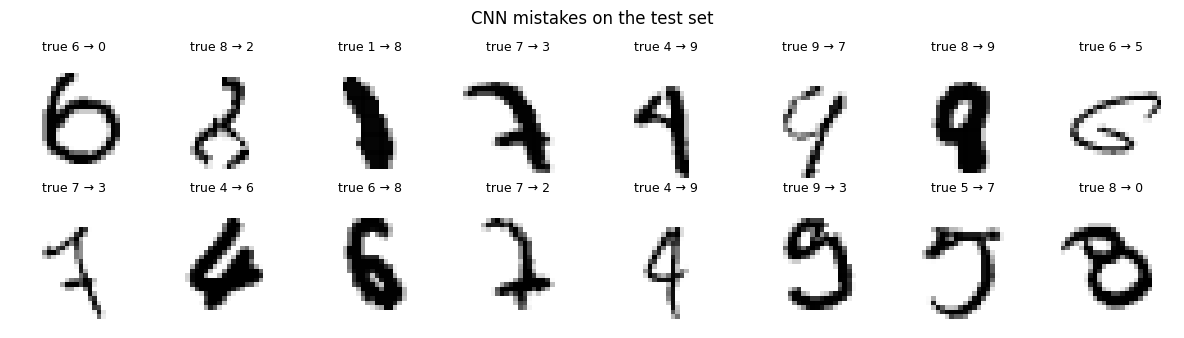

In [6]:
pred = cnn.predict(x_test[..., None], verbose=0).argmax(1)
cm = tf.math.confusion_matrix(y_test, pred).numpy()
per_class = cm.diagonal() / cm.sum(1)
print("CNN per-digit accuracy:", {d: round(float(a), 4) for d, a in enumerate(per_class)})
off = cm.copy(); np.fill_diagonal(off, 0); i, j = np.unravel_index(off.argmax(), off.shape)
print(f"most common confusion: true {i} predicted as {j} ({off[i, j]} images)")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, k in zip(axes.ravel(), np.where(pred != y_test)[0][:16]):
    ax.imshow(x_test[k], cmap="binary"); ax.set_title(f"true {y_test[k]} → {pred[k]}", fontsize=9); ax.axis("off")
plt.suptitle("CNN mistakes on the test set"); plt.tight_layout(); plt.savefig("images/cnn_errors.png", dpi=110); plt.show()